## Bonus Assignment #3

In this assignment, you will work with arrays for numerical analysis and use plotting to visualize the results.

### Assignment 1 – Creating household electricity profiles

Consider a neighbourhood with 10 houses. Each house has its own electricity demand pattern and a different amount of installed solar capacity.

Electricity use is not constant throughout the day. Each house has a small base demand, typically somewhere between 0.2 and 0.5 kWh per hour, but demand tends to increase in the morning and evening. Assume that houses have a morning peak between 07:00 and 09:00 and an evening peak between 17:00 and 21:00. The size of these peaks should differ between houses: add an extra 0.5–1.0 kWh during the morning peak and an extra 0.8–1.5 kWh during the evening peak. Add a small amount of random variation per house to each hourly value so that the profiles are not perfectly smooth.

The houses also have solar panels. Their installed solar capacity differs, with values between 1.5 and 3.5 kW. Solar generation is zero during the night, starts increasing from around 06:00, reaches its maximum around midday, and decreases again towards 18:00. You can represent this daytime pattern using a sine curve.

Write a function called *create_profiles* that creates hourly electricity profiles for all 10 houses over one day. Store the results in NumPy arrays with shape (10, 24), where each row represents a house and each column represents an hour.

The function should create and return:

* `demand`, containing the electricity demand of each house;
* `solar`, containing the solar generation of each house;
* `net_demand`, calculated as: `net demand = electricity demand − solar generation`  A positive net_demand means that a house consumes more electricity than it generates, while a negative value means that it produces more electricity than it consumes.

Hint: Represent the 13 daylight hours from 06:00 to 18:00 using evenly spaced values from 0 to np.pi. Apply np.sin() to these values to create a smooth solar profile that starts at 0, peaks around noon, and returns to 0. Then scale the profile using the house's solar capacity.



In [1]:
import numpy as np
import matplotlib.pyplot as plt


def create_profiles():
    base_demand = np.round(np.random.uniform(0.2, 0.5, size=(10, 24)), 2)
    morning_peak_demand = np.round(np.random.uniform(0.5, 1.0, size=(10,3)), 2)
    evening_peak_demand = np.round(np.random.uniform(0.8, 1.5, size=(10,5)), 2)

    
    demand = base_demand

    demand[:, 7:10] += morning_peak_demand
    demand[:, 17:22] += evening_peak_demand
    
    solar = np.zeros([10, 24])

    x = np.linspace(0, np.pi, 13)
    solar_profile = np.sin(x)

    capacities = np.random.uniform(1.5, 3.5, size=(10, 1))

    solar[:, 6:19] = np.round(capacities * solar_profile, 2)

    net_demand = demand - solar

    return demand, solar, net_demand

np.set_printoptions(linewidth=1000)
create_profiles()

Matplotlib is building the font cache; this may take a moment.


(array([[0.23, 0.31, 0.31, 0.25, 0.43, 0.38, 0.27, 1.26, 1.24, 0.93, 0.48, 0.41, 0.5 , 0.33, 0.38, 0.24, 0.23, 1.4 , 1.58, 1.45, 1.66, 1.14, 0.27, 0.41],
        [0.45, 0.48, 0.29, 0.22, 0.42, 0.4 , 0.28, 1.2 , 1.19, 1.23, 0.35, 0.44, 0.44, 0.46, 0.46, 0.32, 0.44, 1.29, 1.23, 1.11, 1.37, 1.58, 0.28, 0.39],
        [0.45, 0.33, 0.36, 0.26, 0.23, 0.43, 0.42, 0.88, 0.99, 0.89, 0.37, 0.32, 0.23, 0.28, 0.26, 0.38, 0.21, 1.1 , 1.48, 1.24, 1.92, 1.14, 0.21, 0.2 ],
        [0.46, 0.25, 0.29, 0.26, 0.24, 0.47, 0.5 , 1.19, 1.26, 1.12, 0.23, 0.37, 0.38, 0.47, 0.48, 0.22, 0.35, 1.15, 1.78, 1.47, 1.77, 1.8 , 0.36, 0.4 ],
        [0.37, 0.39, 0.46, 0.28, 0.26, 0.43, 0.47, 1.01, 1.  , 1.4 , 0.47, 0.27, 0.49, 0.31, 0.43, 0.4 , 0.28, 1.77, 1.67, 1.22, 1.45, 1.54, 0.4 , 0.27],
        [0.48, 0.39, 0.25, 0.34, 0.43, 0.44, 0.46, 0.84, 1.28, 1.17, 0.48, 0.47, 0.37, 0.34, 0.21, 0.44, 0.4 , 1.39, 1.25, 1.73, 1.54, 1.63, 0.45, 0.26],
        [0.44, 0.34, 0.3 , 0.44, 0.24, 0.31, 0.5 , 0.83, 1.08, 1.01, 0.48, 0

### Assignment 2 – Adding batteries to the neighbourhood

In this neighbourhood, during some hours, a house may generate more electricity than it uses, while at other times it may need electricity from the grid. The neighbourhood is now considering installing a small battery in every house. Each battery can store up to 5 kWh of electricity and is empty at the start of the day.

The idea is simple: when a house produces more solar electricity than it needs, the extra electricity should first be stored in its battery. Later, when the house needs more electricity than its solar panels produce, it should use the electricity stored in the battery before importing electricity from the grid.

However, the battery has limits. It cannot store more than 5 kWh and it cannot provide more electricity than it currently contains. If there is more surplus electricity than the battery can store, the remaining electricity is exported to the grid. If the battery does not contain enough electricity to meet demand, the remaining electricity has to be imported from the grid.

Using the net_demand array from Assignment 1, simulate the battery operation for every house and every hour of the day. Write a function called *simulate_batteries* that returns the following arrays:

- battery_level, which stores the amount of electricity in each house's battery at the end of every hour. For simplicity, assume that no energy is lost when charging or discharging the battery.
- grid_exchange, which stores the electricity exchanged with the grid during each hour. Positive values represent electricity imported from the grid, while negative values represent electricity exported to the grid.

Your simulation should process each house hour by hour, because the battery level in one hour depends on what happened in the previous hours.


In [34]:

def simulate_batteries(demand, solar, net_demand):
    battery_level = np.zeros([10, 24])
    grid_exchange = np.zeros([10, 24])
    for (i, pwr) in enumerate(net_demand):
        battery = 0
        for (e, hourly) in enumerate(pwr):
            grid = 0
            if (hourly < 0):
                battery += abs(hourly)
                if ( battery > 5):
                    grid = -(battery - 5)
                    battery = 5
            else:
                battery -= hourly
                if ( battery < 0):
                    grid = abs(battery)
                    battery = 0
                else:
                    grid -= hourly
            battery_level[i, e] = np.round(battery, 2)
            grid_exchange[i, e] = np.round(grid, 2)
    return battery_level, grid_exchange

demand, solar, net_demand = create_profiles()

battery_level, grid_exchange = simulate_batteries(demand, solar, net_demand)

### Assignment 3 - Plot

Using the grid_exchange array from Assignment 2, calculate the total grid exchange of all 10 houses for each hour of the day.

Create a bar chart showing the total grid exchange over 24 hours. Label your plot clearly with an appropriate title and axis labels, and include a grid to improve readability.

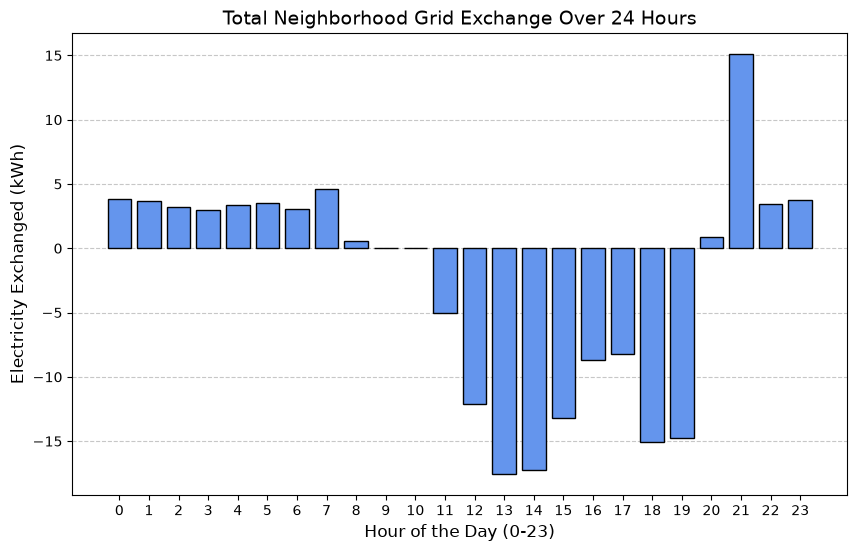

In [41]:

total_grid_exchange = np.sum(grid_exchange, axis=0)

plt.figure(figsize=(10, 6))
plt.bar(range(24), total_grid_exchange, color='cornflowerblue', edgecolor='black', zorder=2)

plt.title("Total Neighborhood Grid Exchange Over 24 Hours", fontsize=14)
plt.xlabel("Hour of the Day (0-23)", fontsize=12)
plt.ylabel("Electricity Exchanged (kWh)", fontsize=12)

plt.xticks(range(24))

plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=1)

plt.show()